In [1]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
img1 = cv2.imread("D:\\VS Code\\Computer_Vision\\Theory_Assignment_01\\box.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("D:\\VS Code\\Computer_Vision\\Theory_Assignment_01\\box_scene.png", cv2.IMREAD_GRAYSCALE)

cv2.imshow("Image 1", img1)
cv2.imshow("Image 2", img2)

cv2.waitKey(0)
cv2.destroyAllWindows()

# ransac_homography_cv

Keypoints in Image 1: 1589
Keypoints in Image 2: 1999
Total Matches: 511
Inliers after RANSAC: 36


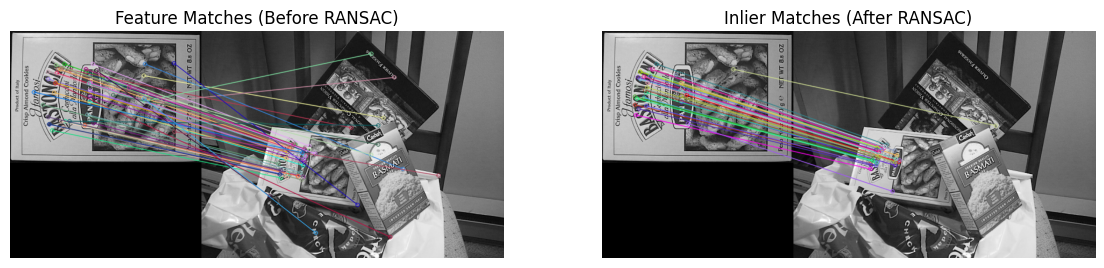

In [3]:
# -------------------------------
# 1. Load Images
# -------------------------------
img1 = cv2.imread("D:\\VS Code\\Computer_Vision\\Theory_Assignment_01\\box.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("D:\\VS Code\\Computer_Vision\\Theory_Assignment_01\\box_scene.png", cv2.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    print("Error loading images.")
    exit()

# -------------------------------
# 2. Detect ORB Features
# -------------------------------
orb = cv2.ORB_create(2000)

kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

print("Keypoints in Image 1:", len(kp1))
print("Keypoints in Image 2:", len(kp2))

# -------------------------------
# 3. Match Features
# -------------------------------
matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = matcher.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

print("Total Matches:", len(matches))

# -------------------------------
# 4. Extract Matched Points
# -------------------------------
pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

# -------------------------------
# 5. Apply Homography
# -------------------------------
def apply_homography(H, point):
    p = np.array([point[0], point[1], 1])
    projected = H @ p
    projected = projected / projected[2]
    return projected[:2]


# -------------------------------
# 6. RANSAC Implementation
# -------------------------------
def compute_homography_ransac(pts1, pts2, iterations=1000, threshold=5):

    best_H = None
    best_inliers = []

    total_points = len(pts1)

    for i in range(iterations):

        # Randomly select 4 correspondences
        idx = random.sample(range(total_points), 4)

        src = pts1[idx]
        dst = pts2[idx]

        # Compute homography
        H, _ = cv2.findHomography(src, dst, 0)

        if H is None:
            continue

        inliers = []

        for j in range(total_points):

            projected = apply_homography(H, pts1[j])

            error = np.linalg.norm(projected - pts2[j])

            if error < threshold:
                inliers.append(j)

        if len(inliers) > len(best_inliers):

            best_inliers = inliers
            best_H = H

    return best_H, best_inliers


# -------------------------------
# 7. Run RANSAC
# -------------------------------
H, inliers = compute_homography_ransac(pts1, pts2)

print("Inliers after RANSAC:", len(inliers))

# -------------------------------
# 8. Visualize Matches
# -------------------------------

# Draw initial matches
img_matches_before = cv2.drawMatches(
    img1, kp1, img2, kp2, matches[:50], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Draw RANSAC inlier matches
inlier_matches = [matches[i] for i in inliers]

img_matches_after = cv2.drawMatches(
    img1, kp1, img2, kp2, inlier_matches[:50], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# -------------------------------
# 9. Show Results
# -------------------------------

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.title("Feature Matches (Before RANSAC)")
plt.imshow(img_matches_before, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Inlier Matches (After RANSAC)")
plt.imshow(img_matches_after, cmap="gray")
plt.axis("off")

plt.show()

# stereo_traffic_monitoring

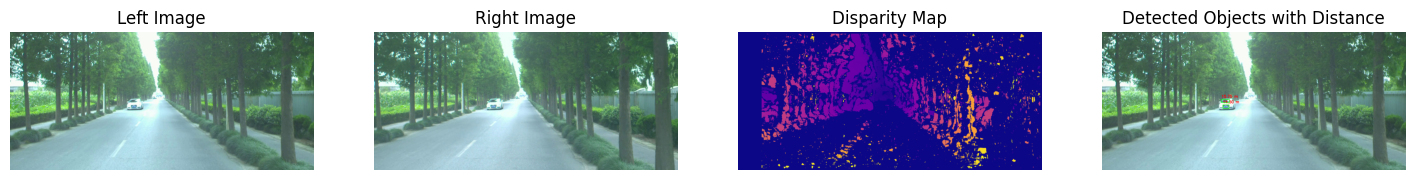

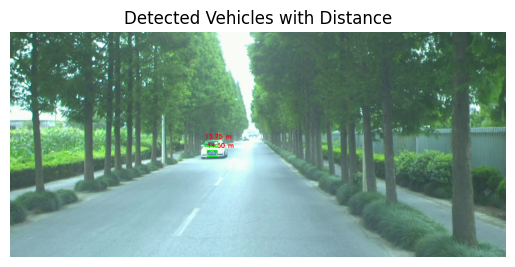

In [4]:

# -----------------------------
# 1. Load Stereo Images
# -----------------------------
left_img = cv2.imread("D:\\VS Code\\Computer_Vision\\Theory_Assignment_01\\left_car.png")
right_img = cv2.imread("D:\\VS Code\\Computer_Vision\\Theory_Assignment_01\\right_car.png")

if left_img is None or right_img is None:
    print("Error: Images not loaded. Check paths.")
    exit()

left_gray = cv2.cvtColor(left_img, cv2.COLOR_BGR2GRAY)
right_gray = cv2.cvtColor(right_img, cv2.COLOR_BGR2GRAY)

# -----------------------------
# 2. Compute Disparity Map
# -----------------------------
# StereoBM requires numDisparities divisible by 16
stereo = cv2.StereoBM_create(numDisparities=128, blockSize=21)

disparity = stereo.compute(left_gray, right_gray).astype(np.float32) / 16.0

# Normalize for visualization
disp_visual = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX)
disp_visual = np.uint8(disp_visual)

# -----------------------------
# 3. Detect Potential Vehicles
# -----------------------------
# Using simple edge detection + contours
blur = cv2.GaussianBlur(left_gray, (5,5), 0)
edges = cv2.Canny(blur, 50, 150)

contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output_img = left_img.copy()

# -----------------------------
# 4. Camera Parameters
# -----------------------------
focal_length = 700     # in pixels (example)
baseline = 0.54        # meters (distance between cameras)

# -----------------------------
# 5. Estimate Distance and Draw
# -----------------------------
for cnt in contours:
    area = cv2.contourArea(cnt)
    
    if area > 500:  # filter small contours (noise) --> 3000
        x, y, w, h = cv2.boundingRect(cnt)
        cx = x + w // 2
        cy = y + h // 2
        
        # Safety check
        if cy >= disparity.shape[0] or cx >= disparity.shape[1]:
            continue
        
        disp_value = disparity[cy, cx]
        
        if disp_value > 0.1:  # ignore zero/negative disparity -->0.1
            depth = (focal_length * baseline) / disp_value
            
            # Draw rectangle around detected object
            cv2.rectangle(output_img, (x, y), (x+w, y+h), (0,255,0), 2)
            # Put distance text
            cv2.putText(
                output_img,
                f"{depth:.2f} m",
                (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0,0,255),
                2
            )

# -----------------------------
# 6. Visualization
# -----------------------------
plt.figure(figsize=(18,6))

plt.subplot(1,4,1)
plt.title("Left Image")
plt.imshow(cv2.cvtColor(left_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,4,2)
plt.title("Right Image")
plt.imshow(cv2.cvtColor(right_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,4,3)
plt.title("Disparity Map")
plt.imshow(disp_visual, cmap='plasma')
plt.axis("off")

plt.subplot(1,4,4)
plt.title("Detected Objects with Distance")
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Detected Vehicles with Distance")
plt.show()


# Optional: show using OpenCV window
cv2.imshow("Traffic Monitoring Output", output_img)
cv2.waitKey(0)
cv2.destroyAllWindows()